# TP2 Run All - Ronda_05 Visual Metric Micro

This notebook is a compact run-all version of the ronda_05 visual-metric micro search. Use **Run All** here instead of running the starter notebook cell by cell.

It is intentionally disk-light:

- loads 144 micro prompts only for `1159_7.png` and `9338.png`;
- keeps the fixed LCM pipeline, fixed per-target seed, and positive textual prompts only;
- adds color-histogram, edge-map and rough-layout metrics to the ranking;
- runs streaming evaluation and saves only top-k rendered candidates plus metrics.

The other targets currently keep their best previous candidates; this run tests whether stricter visual ranking improves the two remaining weak images.


## 1. Setup

Only change the flags below if the environment changes. For the current local setup, the defaults are intended to run directly.


In [1]:
# Optional dependency bootstrap.
# Leave this as False in the local environment that already ran the previous searches.
INSTALL_DEPENDENCIES = False

if INSTALL_DEPENDENCIES:
    import subprocess
    import sys

    requirements = [
        "torch",
        "torchvision",
        "diffusers[torch]",
        "transformers>=4.41,<5",
        "accelerate",
        "safetensors",
        "matplotlib",
        "pandas<3",
        "lpips",
        "Pillow<12",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *requirements])
else:
    print("Dependency install skipped. Set INSTALL_DEPENDENCIES = True only if imports fail.")


Dependency install skipped. Set INSTALL_DEPENDENCIES = True only if imports fail.


## 2. Targets and Utilities


In [2]:
from pathlib import Path
import zipfile
import urllib.request

MOUNT_GOOGLE_DRIVE = False

if MOUNT_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as exc:
        print("Google Drive mount skipped:", exc)

# Optional online URL for a zip with the target images.
# Leave empty if targets are already available locally or in Drive.
TARGETS_ZIP_URL = ""

CONTENT_DIR = Path("/content")
DRIVE_ROOT = Path("/content/drive/MyDrive")
DRIVE_PROJECT_DIR = DRIVE_ROOT / "GENAI_TP2"

LOCAL_BASE_CANDIDATES = [
    Path.cwd(),
    Path("students"),
    Path("TP2-students/students"),
]
LOCAL_PROJECT_DIR = next(
    (candidate for candidate in LOCAL_BASE_CANDIDATES if (candidate / "tp2-chosen").exists()),
    Path("students"),
)

if DRIVE_ROOT.exists():
    DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR = DRIVE_PROJECT_DIR / "outputs"
elif CONTENT_DIR.exists():
    LOCAL_PROJECT_DIR = CONTENT_DIR / "GENAI_TP2"
    OUTPUT_DIR = CONTENT_DIR / "tp2_outputs"
else:
    OUTPUT_DIR = LOCAL_PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

def list_target_images(path):
    path = Path(path)
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        return [path]
    if not path.exists():
        return []
    return sorted(p for p in path.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS)

TARGET_DIR_CANDIDATES = [
    LOCAL_PROJECT_DIR / "tp2-chosen",
    Path("tp2-chosen"),
    Path("students/tp2-chosen"),
    Path("TP2-students/students/tp2-chosen"),
    Path("/content/tp2-chosen"),
    Path("/content/tp2_targets"),
    DRIVE_PROJECT_DIR / "tp2-chosen",
    Path("/content/drive/MyDrive/tp2-chosen"),
    Path("/content/drive/MyDrive/tp2_targets"),
]

ZIP_CANDIDATES = [
    LOCAL_PROJECT_DIR / "tp2-chosen.zip",
    Path("tp2-chosen.zip"),
    Path("students/tp2-chosen.zip"),
    Path("TP2-students/students/tp2-chosen.zip"),
    Path("/content/tp2-chosen.zip"),
    DRIVE_PROJECT_DIR / "tp2-chosen.zip",
    Path("/content/drive/MyDrive/tp2-chosen.zip"),
]

# Download optional online zip.
if TARGETS_ZIP_URL:
    LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    downloaded_zip = LOCAL_PROJECT_DIR / "tp2-chosen.zip"
    urllib.request.urlretrieve(TARGETS_ZIP_URL, downloaded_zip)
    ZIP_CANDIDATES.insert(0, downloaded_zip)
    print("Downloaded targets zip to", downloaded_zip)

# Extract first available zip if no folder with images exists yet.
if not any(list_target_images(candidate) for candidate in TARGET_DIR_CANDIDATES):
    for zip_path in ZIP_CANDIDATES:
        if zip_path.exists():
            extract_dir = Path("/content/tp2-chosen") if CONTENT_DIR.exists() else LOCAL_PROJECT_DIR / "tp2-chosen"
            extract_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path) as zf:
                zf.extractall(extract_dir)
            print(f"Extracted {zip_path} -> {extract_dir}")
            break

TARGET_DIR = None
for candidate in TARGET_DIR_CANDIDATES:
    if list_target_images(candidate):
        TARGET_DIR = candidate
        break

if TARGET_DIR is None:
    raise FileNotFoundError(
        "No target images found. Put images in MyDrive/GENAI_TP2/tp2-chosen, "
        "or put tp2-chosen.zip in MyDrive/GENAI_TP2, or set TARGETS_ZIP_URL."
    )

target_images = list_target_images(TARGET_DIR)
print("Target folder:", TARGET_DIR)
print("Output folder:", OUTPUT_DIR)
print("Number of targets:", len(target_images))
target_images


Target folder: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\tp2-chosen
Output folder: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\outputs
Number of targets: 6


[WindowsPath('c:/Users/tugap/Desktop/Universidade/Masters2ºAno/IAG/Projeto 2/TP2-students/students/tp2-chosen/1159_25.png'),
 WindowsPath('c:/Users/tugap/Desktop/Universidade/Masters2ºAno/IAG/Projeto 2/TP2-students/students/tp2-chosen/1159_29.png'),
 WindowsPath('c:/Users/tugap/Desktop/Universidade/Masters2ºAno/IAG/Projeto 2/TP2-students/students/tp2-chosen/1159_3.png'),
 WindowsPath('c:/Users/tugap/Desktop/Universidade/Masters2ºAno/IAG/Projeto 2/TP2-students/students/tp2-chosen/1159_7.png'),
 WindowsPath('c:/Users/tugap/Desktop/Universidade/Masters2ºAno/IAG/Projeto 2/TP2-students/students/tp2-chosen/7836.png'),
 WindowsPath('c:/Users/tugap/Desktop/Universidade/Masters2ºAno/IAG/Projeto 2/TP2-students/students/tp2-chosen/9338.png')]

In [3]:
import csv
import json
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image


def seed_from_filename(path, fallback=2026):
    match = re.match(r"^(\d+)", Path(path).stem)
    return int(match.group(1)) if match else fallback


def safe_stem(path):
    return "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in Path(path).stem)


def load_image(path):
    return Image.open(path).convert("RGB")


def create_run_dir(base_dir=OUTPUT_DIR, identity="student_run"):
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = Path(base_dir) / f"{timestamp}_{identity}"
    run_dir.mkdir(parents=True, exist_ok=False)
    return run_dir


def write_csv(path, rows):
    rows = list(rows)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        Path(path).write_text("")
        return
    fieldnames = []
    for row in rows:
        for key in row.keys():
            if key not in fieldnames:
                fieldnames.append(key)
    with open(path, "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def show_images(paths, cols=3, title=None):
    paths = list(paths)
    if not paths:
        print("No images to show.")
        return
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    for ax in [ax for row in axes for ax in row]:
        ax.axis("off")
    for ax, path in zip([ax for row in axes for ax in row], paths):
        ax.imshow(load_image(path))
        ax.set_title(Path(path).name)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


for path in target_images:
    print(Path(path).name, "-> seed", seed_from_filename(path))


1159_25.png -> seed 1159
1159_29.png -> seed 1159
1159_3.png -> seed 1159
1159_7.png -> seed 1159
7836.png -> seed 7836
9338.png -> seed 9338


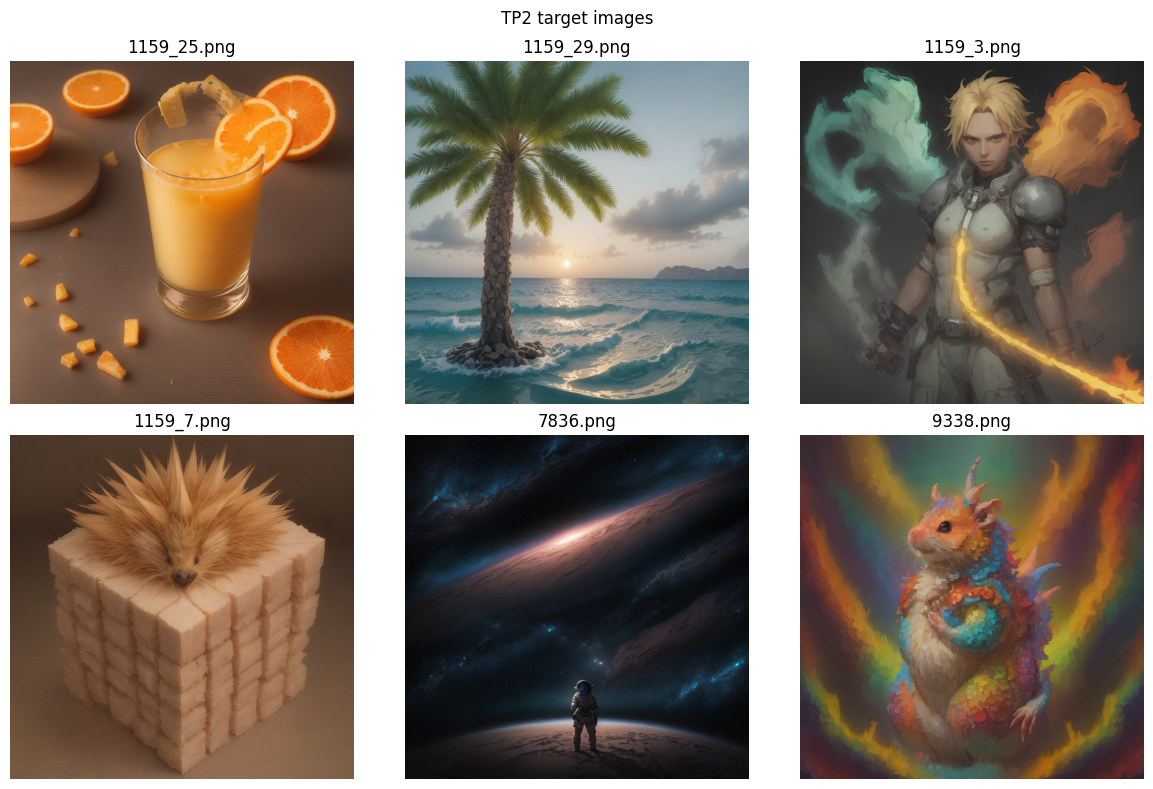

In [4]:
show_images(target_images, cols=3, title="TP2 target images")


## 3. Load Generator


In [5]:
from dataclasses import dataclass
import torch
from diffusers import DiffusionPipeline


@dataclass(frozen=True)
class LCMConfig:
    model_id: str = "SimianLuo/LCM_Dreamshaper_v7"
    seed: int = 2026  # fallback only; target filenames define the real render seed
    num_inference_steps: int = 8
    guidance_scale: float = 8.0
    lcm_origin_steps: int = 50
    width: int = 768
    height: int = 768


config = LCMConfig()


def default_device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


device = default_device()
print("Using device:", device)


def load_lcm_pipeline(config):
    dtype = torch.float16 if device == "cuda" else torch.float32
    pipe = DiffusionPipeline.from_pretrained(
        config.model_id,
        torch_dtype=dtype,
        use_safetensors=True,
    )
    if hasattr(pipe, "safety_checker"):
        pipe.safety_checker = None
    pipe.to(device)
    return pipe


pipe = load_lcm_pipeline(config)


C:\Users\tugap\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Loading pipeline components...: 100%|██████████| 7/7 [00:06<00:00,  1.17it/s]


In [6]:
def render_prompt(prompt, seed, pipe=pipe, config=config, negative_prompt=""):
    generator_device = "cpu" if device == "mps" else device
    generator = torch.Generator(device=generator_device).manual_seed(seed)
    image = pipe(
        prompt=prompt,
        num_inference_steps=config.num_inference_steps,
        guidance_scale=config.guidance_scale,
        original_inference_steps=config.lcm_origin_steps,
        width=config.width,
        height=config.height,
        output_type="pil",
        generator=generator,
    ).images[0]
    return image


def render_prompt_for_target(prompt, target_path, negative_prompt=""):
    seed = seed_from_filename(target_path, config.seed)
    return render_prompt(prompt, seed=seed)


def save_generated_image(image, run_dir, target_path, prompt_index=1):
    target_dir = Path(run_dir) / safe_stem(target_path)
    target_dir.mkdir(parents=True, exist_ok=True)
    path = target_dir / f"candidate_{prompt_index:03d}.png"
    image.save(path)
    return path


## 4. Load Ronda_05 Prompts


In [7]:
# Final ronda_05 visual-metric micro prompt bank loader.
# This keeps the notebook small and avoids executing the old prompt-generation cells.

from collections import Counter
import json
from pathlib import Path

AUTO_SEARCH_MODE = "ronda_05_visual_metric_micro"
PROMPT_BANK_CANDIDATES = [
    Path("prompts/refinement_ronda_05_visual_metric_micro.json"),
    Path("../prompts/refinement_ronda_05_visual_metric_micro.json"),
    Path("../../prompts/refinement_ronda_05_visual_metric_micro.json"),
    Path.cwd() / "prompts" / "refinement_ronda_05_visual_metric_micro.json",
    Path.cwd().parent / "prompts" / "refinement_ronda_05_visual_metric_micro.json",
    Path.cwd().parent.parent / "prompts" / "refinement_ronda_05_visual_metric_micro.json",
]

PROMPT_BANK_PATH = next((path for path in PROMPT_BANK_CANDIDATES if path.exists()), None)
if PROMPT_BANK_PATH is None:
    raise FileNotFoundError(
        "Could not find prompts/refinement_ronda_05_visual_metric_micro.json. "
        "Run the notebook from the project root or from TP2-students/students."
    )

raw_prompt_bank = json.loads(PROMPT_BANK_PATH.read_text(encoding="utf-8"))
auto_candidate_prompts = {}
for target_name, entries in raw_prompt_bank.items():
    cleaned = []
    for index, entry in enumerate(entries, start=1):
        if isinstance(entry, str):
            cleaned.append({"prompt": entry, "negative_prompt": "", "source": AUTO_SEARCH_MODE, "id": f"{Path(target_name).stem}_{index:03d}"})
        else:
            cleaned.append({
                "prompt": str(entry.get("prompt", "")),
                "negative_prompt": "",
                "source": str(entry.get("source", AUTO_SEARCH_MODE)),
                "id": str(entry.get("id", f"{Path(target_name).stem}_{index:03d}")),
            })
    auto_candidate_prompts[target_name] = cleaned

counts = {target: len(entries) for target, entries in auto_candidate_prompts.items()}
print("Prompt bank:", PROMPT_BANK_PATH)
print("Mode:", AUTO_SEARCH_MODE)
print("Total Ronda_05 prompts:", sum(counts.values()))
for target, count in sorted(counts.items()):
    print(f"  {target}: {count}")


Prompt bank: ..\..\prompts\refinement_ronda_05_visual_metric_micro.json
Mode: ronda_05_visual_metric_micro
Total Ronda_05 prompts: 144
  1159_7.png: 72
  9338.png: 72


## 5. Run Search

This is the long cell. It renders and evaluates all round20 prompts in memory, saving only metrics and top-k images.


In [8]:
# Disk-light automatic search: save only top-k renders.
# Requires sections 1-5 to be executed first.

STREAM_OFFLINE_MODE = True
STREAM_TARGETS = None  # e.g. ["1159_7.png", "9338.png"] or None for all auto targets
STREAM_LIMIT_PER_TARGET = 0  # set to e.g. 5 for a quick smoke test; 0 means all prompts
STREAM_TOP_K = 5
STREAM_CHECKPOINT_EVERY = 0  # disabled by default to avoid duplicate partial metric files
STREAM_WRITE_JSON = False  # CSV is enough for analysis; JSON metrics are large
STREAM_PRINT_EVERY = 10  # reduce notebook output while keeping progress visible
STREAM_SAVE_TOP_AFTER_EACH_TARGET = True  # saves top-k images as soon as each target finishes
STREAM_PARETO_BONUS = 0.03  # small tie-breaker for candidates not dominated across CLIP/LPIPS/RMSE/SSIM
STREAM_DEFAULT_SCORE_WEIGHTS = {"clip": 0.28, "lpips": 0.32, "rmse": 0.12, "ssim": 0.08, "color": 0.10, "edge": 0.06, "layout": 0.04}
STREAM_SCORE_WEIGHTS_BY_TARGET = {
    "9338.png": {"clip": 0.20, "lpips": 0.28, "rmse": 0.12, "ssim": 0.10, "color": 0.16, "edge": 0.09, "layout": 0.05},
    "1159_3.png": {"clip": 0.34, "lpips": 0.25, "rmse": 0.16, "ssim": 0.08, "color": 0.08, "edge": 0.06, "layout": 0.03},
    "1159_7.png": {"clip": 0.12, "lpips": 0.34, "rmse": 0.15, "ssim": 0.13, "color": 0.09, "edge": 0.12, "layout": 0.05},
    "1159_25.png": {"clip": 0.25, "lpips": 0.36, "rmse": 0.12, "ssim": 0.08, "color": 0.12, "edge": 0.04, "layout": 0.03},
    "1159_29.png": {"clip": 0.34, "lpips": 0.30, "rmse": 0.10, "ssim": 0.08, "color": 0.09, "edge": 0.05, "layout": 0.04},
    "7836.png": {"clip": 0.16, "lpips": 0.16, "rmse": 0.20, "ssim": 0.26, "color": 0.10, "edge": 0.08, "layout": 0.04},
}
STREAM_METRIC_DEVICE = "cpu"  # keep metrics on CPU so the LCM can stay on GPU
STREAM_CLIP_MODEL_ID = "openai/clip-vit-large-patch14"
STREAM_RUN_IDENTITY = f"notebook_{AUTO_SEARCH_MODE}" if "AUTO_SEARCH_MODE" in globals() else "notebook_streaming_auto_search"

import math
import os
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torchvision.transforms import functional as TF

if STREAM_OFFLINE_MODE:
    os.environ["HF_HUB_OFFLINE"] = "1"
    os.environ["TRANSFORMERS_OFFLINE"] = "1"

try:
    pipe.to(device)
    if device == "cuda":
        torch.cuda.empty_cache()
    print("LCM render device:", device)
except Exception as exc:
    print("Could not move LCM pipeline to render device:", exc)

from transformers import CLIPImageProcessor, CLIPModel
import lpips

local_only = os.environ.get("HF_HUB_OFFLINE") == "1" or os.environ.get("TRANSFORMERS_OFFLINE") == "1"
clip_processor = CLIPImageProcessor.from_pretrained(STREAM_CLIP_MODEL_ID, local_files_only=local_only)
clip_model = CLIPModel.from_pretrained(STREAM_CLIP_MODEL_ID, local_files_only=local_only).to(STREAM_METRIC_DEVICE).eval()
lpips_model = lpips.LPIPS(net="alex").to(STREAM_METRIC_DEVICE).eval()


def stream_pil_to_lpips_tensor(image, metric_device):
    tensor = TF.to_tensor(image).unsqueeze(0)
    return (tensor * 2.0 - 1.0).to(metric_device)


def stream_global_ssim(target_arr, render_arr):
    weights = np.asarray([0.299, 0.587, 0.114], dtype=np.float32)
    if target_arr.ndim == 3:
        target_gray = (target_arr[..., :3] * weights).sum(axis=2)
        render_gray = (render_arr[..., :3] * weights).sum(axis=2)
    else:
        target_gray = target_arr
        render_gray = render_arr
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    mu_x = float(target_gray.mean())
    mu_y = float(render_gray.mean())
    var_x = float(((target_gray - mu_x) ** 2).mean())
    var_y = float(((render_gray - mu_y) ** 2).mean())
    cov_xy = float(((target_gray - mu_x) * (render_gray - mu_y)).mean())
    denom = (mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2)
    if abs(denom) < 1e-12:
        return 0.0
    return float(max(-1.0, min(1.0, ((2 * mu_x * mu_y + c1) * (2 * cov_xy + c2)) / denom)))


def stream_pixel_metrics(target, render):
    if target.size != render.size:
        render = render.resize(target.size, Image.Resampling.BICUBIC)
    target_arr = np.asarray(target, dtype=np.float32) / 255.0
    render_arr = np.asarray(render, dtype=np.float32) / 255.0
    mse = float(np.mean((target_arr - render_arr) ** 2))
    return mse, float(math.sqrt(mse)), stream_global_ssim(target_arr, render_arr)


def stream_rgb_arrays(target, render):
    if target.size != render.size:
        render = render.resize(target.size, Image.Resampling.BICUBIC)
    return np.asarray(target.convert("RGB"), dtype=np.float32) / 255.0, np.asarray(render.convert("RGB"), dtype=np.float32) / 255.0


def stream_color_hist_similarity(target_arr, render_arr, bins=32):
    scores = []
    for channel in range(3):
        target_hist, _ = np.histogram(target_arr[..., channel], bins=bins, range=(0.0, 1.0), density=False)
        render_hist, _ = np.histogram(render_arr[..., channel], bins=bins, range=(0.0, 1.0), density=False)
        target_hist = target_hist.astype(np.float64) / (target_hist.sum() or 1.0)
        render_hist = render_hist.astype(np.float64) / (render_hist.sum() or 1.0)
        scores.append(float(np.minimum(target_hist, render_hist).sum()))
    return float(np.mean(scores))


def stream_sobel_edges(gray):
    padded = np.pad(gray, 1, mode="edge")
    gx = -padded[:-2, :-2] - 2 * padded[1:-1, :-2] - padded[2:, :-2] + padded[:-2, 2:] + 2 * padded[1:-1, 2:] + padded[2:, 2:]
    gy = -padded[:-2, :-2] - 2 * padded[:-2, 1:-1] - padded[:-2, 2:] + padded[2:, :-2] + 2 * padded[2:, 1:-1] + padded[2:, 2:]
    edges = np.sqrt(gx * gx + gy * gy)
    return edges / (float(edges.max()) + 1e-8)


def stream_edge_similarity(target_arr, render_arr):
    weights = np.asarray([0.299, 0.587, 0.114], dtype=np.float32)
    target_edges = stream_sobel_edges((target_arr[..., :3] * weights).sum(axis=2))
    render_edges = stream_sobel_edges((render_arr[..., :3] * weights).sum(axis=2))
    rmse = float(math.sqrt(float(np.mean((target_edges - render_edges) ** 2))))
    return rmse, float(max(0.0, min(1.0, 1.0 - rmse)))


def stream_saliency_center(arr):
    gray = (arr[..., :3] * np.asarray([0.299, 0.587, 0.114], dtype=np.float32)).sum(axis=2)
    saliency = np.abs(gray - float(np.median(gray))) + 0.5 * (arr.max(axis=2) - arr.min(axis=2))
    total = float(saliency.sum())
    height, width = saliency.shape
    if total < 1e-8:
        return 0.5, 0.5, 0.5, 0.5
    yy, xx = np.mgrid[0:height, 0:width]
    cx = float((saliency * xx).sum() / total / max(1, width - 1))
    cy = float((saliency * yy).sum() / total / max(1, height - 1))
    sx = float(math.sqrt(float((saliency * ((xx / max(1, width - 1)) - cx) ** 2).sum() / total)))
    sy = float(math.sqrt(float((saliency * ((yy / max(1, height - 1)) - cy) ** 2).sum() / total)))
    return cx, cy, sx, sy


def stream_layout_similarity(target_arr, render_arr):
    target_center = stream_saliency_center(target_arr)
    render_center = stream_saliency_center(render_arr)
    distance = math.sqrt(sum((a - b) ** 2 for a, b in zip(target_center, render_center)))
    return float(max(0.0, min(1.0, 1.0 - distance)))


def stream_visual_specific_metrics(target, render):
    target_arr, render_arr = stream_rgb_arrays(target, render)
    edge_rmse, edge_sim = stream_edge_similarity(target_arr, render_arr)
    color_sim = stream_color_hist_similarity(target_arr, render_arr)
    layout_sim = stream_layout_similarity(target_arr, render_arr)
    return {
        "color_hist_sim": color_sim,
        "edge_rmse": edge_rmse,
        "edge_sim": edge_sim,
        "layout_sim": layout_sim,
        "visual_specific_score": 0.45 * color_sim + 0.35 * edge_sim + 0.20 * layout_sim,
    }


@torch.no_grad()
def stream_clip_image_embedding(image):
    inputs = clip_processor(images=image, return_tensors="pt")
    inputs = {key: value.to(STREAM_METRIC_DEVICE) for key, value in inputs.items()}
    embedding = clip_model.get_image_features(**inputs)
    if hasattr(embedding, "pooler_output"):
        embedding = embedding.pooler_output
    elif hasattr(embedding, "image_embeds"):
        embedding = embedding.image_embeds
    elif isinstance(embedding, (tuple, list)):
        embedding = embedding[0]
    return embedding / embedding.norm(dim=-1, keepdim=True)


def stream_minmax_good(values, higher_is_better):
    lo, hi = min(values), max(values)
    if abs(hi - lo) < 1e-12:
        return [0.5 for _ in values]
    scaled = [(value - lo) / (hi - lo) for value in values]
    return scaled if higher_is_better else [1.0 - value for value in scaled]


def stream_weights_for_target(target_name):
    weights = dict(STREAM_DEFAULT_SCORE_WEIGHTS)
    weights.update(STREAM_SCORE_WEIGHTS_BY_TARGET.get(target_name, {}))
    total = sum(float(value) for value in weights.values()) or 1.0
    return {key: float(value) / total for key, value in weights.items()}


def stream_mark_pareto(group):
    for row in group:
        row["is_pareto"] = True
        row["pareto_rank"] = 0
    for row in group:
        for other in group:
            if row is other:
                continue
            better_or_equal = (
                float(other["clip_iisim"]) >= float(row["clip_iisim"]) and
                float(other["lpips_alex"]) <= float(row["lpips_alex"]) and
                float(other["pixel_rmse_01"]) <= float(row["pixel_rmse_01"]) and
                float(other.get("pixel_ssim_01", 0.0)) >= float(row.get("pixel_ssim_01", 0.0))
            )
            strictly_better = (
                float(other["clip_iisim"]) > float(row["clip_iisim"]) or
                float(other["lpips_alex"]) < float(row["lpips_alex"]) or
                float(other["pixel_rmse_01"]) < float(row["pixel_rmse_01"]) or
                float(other.get("pixel_ssim_01", 0.0)) > float(row.get("pixel_ssim_01", 0.0))
            )
            if better_or_equal and strictly_better:
                row["is_pareto"] = False
                row["pareto_rank"] = 1
                break


def stream_add_combined_scores(metric_rows):
    by_target = defaultdict(list)
    for row in metric_rows:
        by_target[row["target_name"]].append(row)
    for target_name, group in by_target.items():
        clip_good = stream_minmax_good([row["clip_iisim"] for row in group], True)
        lpips_good = stream_minmax_good([row["lpips_alex"] for row in group], False)
        rmse_good = stream_minmax_good([row["pixel_rmse_01"] for row in group], False)
        ssim_good = stream_minmax_good([row.get("pixel_ssim_01", 0.0) for row in group], True)
        color_good = stream_minmax_good([row.get("color_hist_sim", 0.5) for row in group], True)
        edge_good = stream_minmax_good([row.get("edge_sim", 0.5) for row in group], True)
        layout_good = stream_minmax_good([row.get("layout_sim", 0.5) for row in group], True)
        weights = stream_weights_for_target(target_name)
        for row, c, l, r, s, color, edge, layout in zip(group, clip_good, lpips_good, rmse_good, ssim_good, color_good, edge_good, layout_good):
            row["clip_norm"] = c
            row["lpips_norm"] = l
            row["rmse_norm"] = r
            row["ssim_norm"] = s
            row["color_norm"] = color
            row["edge_norm"] = edge
            row["layout_norm"] = layout
            row["combined_score"] = (
                weights.get("clip", 0.0) * c +
                weights.get("lpips", 0.0) * l +
                weights.get("rmse", 0.0) * r +
                weights.get("ssim", 0.0) * s +
                weights.get("color", 0.0) * color +
                weights.get("edge", 0.0) * edge +
                weights.get("layout", 0.0) * layout
            )
        stream_mark_pareto(group)
        for row in group:
            row["selection_score"] = float(row["combined_score"]) + (STREAM_PARETO_BONUS if row["is_pareto"] else 0.0)


def stream_aggregate(metric_rows):
    summary = {}
    for metric in ["clip_iisim", "lpips_alex", "pixel_mse_01", "pixel_rmse_01", "pixel_ssim_01", "color_hist_sim", "edge_sim", "layout_sim", "visual_specific_score", "combined_score", "selection_score"]:
        values = np.asarray([float(row[metric]) for row in metric_rows], dtype=np.float64)
        summary[metric] = {
            "mean": float(values.mean()) if len(values) else float("nan"),
            "std": float(values.std(ddof=1)) if len(values) > 1 else 0.0,
        }
    return summary


def stream_write_partial_metrics(run_dir, metric_rows, label="partial"):
    if not metric_rows:
        return
    write_csv(run_dir / f"metrics_{label}.csv", metric_rows)
    if STREAM_WRITE_JSON:
        (run_dir / f"metrics_{label}.json").write_text(
            json.dumps(metric_rows, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )


def stream_save_target_top(run_dir, target_name, target_rows, partial_top_rows):
    if not target_rows:
        return
    stream_add_combined_scores(target_rows)
    ranked = sorted(target_rows, key=lambda item: -float(item.get("selection_score", item["combined_score"])))
    seed = int(ranked[0]["render_seed"])
    target_path = Path(ranked[0]["target"])
    target_output_dir = run_dir / safe_stem(target_path)
    target_output_dir.mkdir(parents=True, exist_ok=True)
    target_top_rows = []
    for rank, row in enumerate(ranked[:STREAM_TOP_K], start=1):
        top_row = dict(row)
        generated = stream_render_prompt(top_row["prompt"], seed=seed, negative_prompt=top_row.get("negative_prompt", ""))
        image_path = target_output_dir / f"rank_{rank:02d}_candidate_{int(top_row['candidate_index']):03d}.png"
        generated.save(image_path)
        top_row["rank"] = rank
        top_row["render"] = str(image_path)
        top_row["render_path"] = str(image_path)
        target_top_rows.append(top_row)
        del generated
    partial_top_rows[:] = [row for row in partial_top_rows if row["target_name"] != target_name]
    partial_top_rows.extend(target_top_rows)
    write_csv(run_dir / f"top{STREAM_TOP_K}_partial.csv", partial_top_rows)
    if STREAM_WRITE_JSON:
        (run_dir / f"top{STREAM_TOP_K}_partial.json").write_text(
            json.dumps(partial_top_rows, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
    print(f"Saved partial top-{STREAM_TOP_K} for {target_name}")


def stream_prompt_text(entry):
    return str(entry.get("prompt", "")) if isinstance(entry, dict) else str(entry)


def stream_negative_prompt(entry):
    # LatentConsistencyModelPipeline ignores negative prompts. Keep this column
    # empty so the search budget is interpreted as positive prompt variation.
    return ""


def stream_render_prompt(prompt, seed, negative_prompt=""):
    return render_prompt(prompt, seed=seed)


if "target_images" not in globals():
    raise NameError(
        "target_images is not defined. Run notebook sections 2 and 3 first: "
        "2. Google Drive and Target Paths -> 3. Utilities. "
        "If the kernel was restarted, run 2 -> 3 -> 4 -> 5 -> 11.1 -> 11.2."
    )
if "pipe" not in globals() or "config" not in globals():
    raise NameError(
        "The LCM pipeline is not loaded. Run section 4 first. "
        "Recommended order after a kernel restart: 2 -> 3 -> 4 -> 5 -> 11.1 -> 11.2."
    )
if "auto_candidate_prompts" not in globals():
    raise NameError("auto_candidate_prompts is not defined. Run 11.1 before 11.2.")

target_by_name = {Path(path).name: path for path in target_images}
selected_names = STREAM_TARGETS or list(auto_candidate_prompts.keys())
run_dir = create_run_dir(identity=STREAM_RUN_IDENTITY)
metric_rows = []
partial_top_rows = []

total = 0
for image_name in selected_names:
    prompts = auto_candidate_prompts.get(image_name, [])
    total += len(prompts[:STREAM_LIMIT_PER_TARGET] if STREAM_LIMIT_PER_TARGET else prompts)

counter = 0
for image_name in selected_names:
    target_path = target_by_name.get(image_name)
    if target_path is None:
        print("Skipping unknown target:", image_name)
        continue
    prompts = auto_candidate_prompts.get(image_name, [])
    prompts_to_run = prompts[:STREAM_LIMIT_PER_TARGET] if STREAM_LIMIT_PER_TARGET else prompts
    if not prompts_to_run:
        print("Skipping target without prompts:", image_name)
        continue

    target_image = load_image(target_path)
    target_clip = stream_clip_image_embedding(target_image)
    target_lpips = stream_pil_to_lpips_tensor(target_image, STREAM_METRIC_DEVICE)
    seed = seed_from_filename(target_path, config.seed)

    for index, entry in enumerate(prompts_to_run, start=1):
        counter += 1
        prompt = stream_prompt_text(entry)
        negative_prompt = stream_negative_prompt(entry)
        should_print = (
            index == 1 or
            index == len(prompts_to_run) or
            counter % STREAM_PRINT_EVERY == 0
        )
        if should_print:
            print(f"[{counter}/{total}] {image_name} #{index:03d}: {prompt}")
            if negative_prompt:
                print("  negative:", negative_prompt)
        generated = stream_render_prompt(prompt, seed=seed, negative_prompt=negative_prompt)
        if generated.size != target_image.size:
            generated = generated.resize(target_image.size, Image.Resampling.BICUBIC)

        render_clip = stream_clip_image_embedding(generated)
        clip_iisim = float((target_clip * render_clip).sum().item())
        with torch.no_grad():
            lpips_alex = float(lpips_model(
                target_lpips,
                stream_pil_to_lpips_tensor(generated, STREAM_METRIC_DEVICE),
            ).item())
        pixel_mse, pixel_rmse, pixel_ssim = stream_pixel_metrics(target_image, generated)
        visual_metrics = stream_visual_specific_metrics(target_image, generated)
        metric_rows.append({
            "target_name": image_name,
            "target": str(target_path),
            "render_seed": seed,
            "candidate_index": index,
            "prompt": prompt,
            "negative_prompt": negative_prompt,
            "clip_model": STREAM_CLIP_MODEL_ID,
            "clip_iisim": clip_iisim,
            "lpips_alex": lpips_alex,
            "pixel_mse_01": pixel_mse,
            "pixel_rmse_01": pixel_rmse,
            "pixel_ssim_01": pixel_ssim,
            **visual_metrics,
            "model_id": config.model_id,
            "num_inference_steps": config.num_inference_steps,
            "guidance_scale": config.guidance_scale,
            "original_inference_steps": config.lcm_origin_steps,
            "width": config.width,
            "height": config.height,
        })
        del generated, render_clip
        if STREAM_CHECKPOINT_EVERY and counter % STREAM_CHECKPOINT_EVERY == 0:
            stream_write_partial_metrics(run_dir, metric_rows, "partial")

    target_rows = [row for row in metric_rows if row["target_name"] == image_name]
    if STREAM_SAVE_TOP_AFTER_EACH_TARGET:
        stream_save_target_top(run_dir, image_name, target_rows, partial_top_rows)
    stream_write_partial_metrics(run_dir, metric_rows, "partial")

stream_add_combined_scores(metric_rows)
write_csv(run_dir / "metrics.csv", metric_rows)
if STREAM_WRITE_JSON:
    (run_dir / "metrics.json").write_text(json.dumps(metric_rows, indent=2, ensure_ascii=False), encoding="utf-8")

grouped = defaultdict(list)
for row in metric_rows:
    grouped[row["target_name"]].append(row)

top_rows = []
for target_name in sorted(grouped):
    ranked = sorted(grouped[target_name], key=lambda item: -float(item.get("selection_score", item["combined_score"])))
    seed = int(ranked[0]["render_seed"])
    target_path = Path(ranked[0]["target"])
    target_output_dir = run_dir / safe_stem(target_path)
    target_output_dir.mkdir(parents=True, exist_ok=True)
    for rank, row in enumerate(ranked[:STREAM_TOP_K], start=1):
        top_row = dict(row)
        generated = stream_render_prompt(top_row["prompt"], seed=seed, negative_prompt=top_row.get("negative_prompt", ""))
        image_path = target_output_dir / f"rank_{rank:02d}_candidate_{int(top_row['candidate_index']):03d}.png"
        generated.save(image_path)
        top_row["rank"] = rank
        top_row["render"] = str(image_path)
        top_row["render_path"] = str(image_path)
        top_rows.append(top_row)

write_csv(run_dir / f"top{STREAM_TOP_K}.csv", top_rows)
if STREAM_WRITE_JSON:
    (run_dir / f"top{STREAM_TOP_K}.json").write_text(json.dumps(top_rows, indent=2, ensure_ascii=False), encoding="utf-8")
summary = {
    "all_candidates": stream_aggregate(metric_rows),
    f"top{STREAM_TOP_K}": stream_aggregate(top_rows),
    "mode": "streaming: candidates rendered in memory; only top-k images saved",
    "ranking_score": "target-specific weighted normalised CLIP/LPIPS/RMSE/SSIM/color/edge/layout plus a small Pareto-front bonus",
}
(run_dir / "summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("Saved streaming run to:", run_dir)
pd.DataFrame(top_rows)[["target_name", "rank", "candidate_index", "clip_iisim", "lpips_alex", "pixel_rmse_01", "pixel_ssim_01", "color_hist_sim", "edge_sim", "layout_sim", "is_pareto", "selection_score", "prompt"]]


LCM render device: cuda
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


C:\Users\tugap\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\tugap\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth


c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\.venv\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict

[1/144] 1159_7.png #001: pale wooden cube hedgehog sculpture, vertical 4 by 4 block grid on the front and side, tiny dark face recessed in the top center, dense tan orange spines rising from the top plane, warm brown studio render


...

100%|██████████| 8/8 [00:08<00:00,  1.03s/it]


Saved partial top-5 for 9338.png


100%|██████████| 8/8 [00:08<00:00,  1.01s/it]


Saved streaming run to: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\outputs\20260518-173348_notebook_ronda_05_visual_metric_micro


,target_name,rank,candidate_index,clip_iisim,lpips_alex,pixel_rmse_01,pixel_ssim_01,color_hist_sim,edge_sim,layout_sim,is_pareto,selection_score,prompt
0,1159_7.png,1,59,0.744552,0.413678,0.129166,0.508053,0.747781,0.921537,0.957232,True,0.843189,small hedgehog face inside a tiled wooden cube...
1,1159_7.png,2,55,0.616159,0.444230,0.110921,0.715714,0.753976,0.924348,0.992218,True,0.838113,"closed pale timber cube creature, front wall m..."
2,1159_7.png,3,68,0.713839,0.441449,0.132229,0.653543,0.711625,0.923581,0.978663,True,0.806663,"compact square wood-block hedgehog object, fro..."
3,1159_7.png,4,69,0.808421,0.466871,0.135722,0.661536,0.655906,0.923712,0.985621,True,0.776063,"cubical hedgehog fused into a pale wood block,..."
4,1159_7.png,5,52,0.588288,0.460945,0.103970,0.741152,0.713125,0.922333,0.980255,True,0.773887,"compact square wood-block hedgehog object, sta..."
5,9338.png,1,31,0.773972,0.570365,0.143254,0.509174,0.724615,0.940490,0.958359,True,0.873703,"upright fantasy spiny creature, orange animal ..."
6,9338.png,2,7,0.757622,0.589525,0.138861,0.518377,0.743721,0.931195,0.969494,True,0.812689,"upright fantasy spiny creature, orange animal ..."
7,9338.png,3,30,0.748072,0.602662,0.149332,0.522030,0.728964,0.944479,0.975832,True,0.795325,"upright fantasy spiny creature, orange animal ..."
8,9338.png,4,25,0.726661,0.601861,0.138166,0.519069,0.777323,0.944792,0.968468,True,0.793872,"upright fantasy spiny creature, orange animal ..."
9,9338.png,5,64,0.745560,0.604826,0.136480,0.474306,0.783309,0.937217,0.969728,True,0.777225,"tiny echidna-like creature portrait, warm oran..."


## 6. Results


Saved contact sheet: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\outputs\20260518-173348_notebook_ronda_05_visual_metric_micro\contact_sheet_top5.jpg


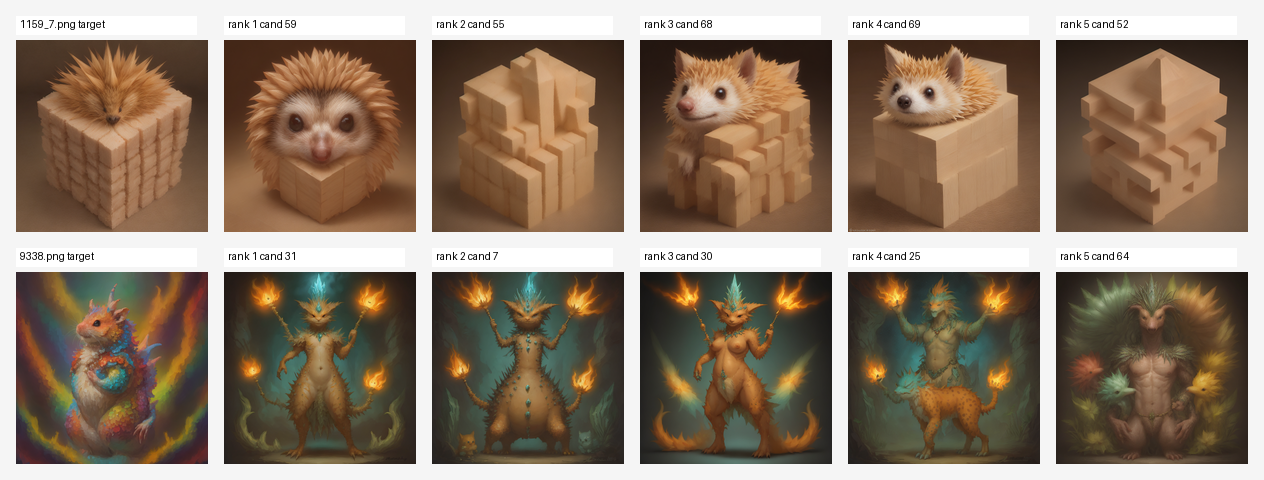

In [9]:
# Contact sheet for the streaming search top-k.

from PIL import ImageDraw, ImageFont


def stream_fit_square(image, size):
    image = image.copy()
    image.thumbnail((size, size), Image.Resampling.LANCZOS)
    canvas = Image.new("RGB", (size, size), "white")
    canvas.paste(image, ((size - image.width) // 2, (size - image.height) // 2))
    return canvas


def stream_draw_label(draw, xy, text, font):
    x, y = xy
    draw.rectangle((x, y, x + 180, y + 18), fill=(255, 255, 255))
    draw.text((x + 4, y + 2), text, fill=(0, 0, 0), font=font)

thumb = 192
gap = 16
label_height = 24
columns = min(int(STREAM_TOP_K) + 1, 6)
by_target = defaultdict(list)
for row in top_rows:
    by_target[row["target_name"]].append(row)
for group in by_target.values():
    group.sort(key=lambda item: int(item["rank"]))

sheet_width = columns * thumb + (columns + 1) * gap
row_height = thumb + label_height + gap
sheet_height = len(by_target) * row_height + gap
sheet = Image.new("RGB", (sheet_width, sheet_height), (245, 245, 245))
draw = ImageDraw.Draw(sheet)
font = ImageFont.load_default()

for row_index, target_name in enumerate(sorted(by_target)):
    y = gap + row_index * row_height
    group = by_target[target_name]
    target = stream_fit_square(load_image(group[0]["target"]), thumb)
    x = gap
    sheet.paste(target, (x, y + label_height))
    stream_draw_label(draw, (x, y), f"{target_name} target", font)

    for col_index, row in enumerate(group[: int(STREAM_TOP_K)], start=1):
        x = gap + col_index * (thumb + gap)
        render_path = row.get("render") or row.get("render_path")
        render = stream_fit_square(load_image(render_path), thumb)
        sheet.paste(render, (x, y + label_height))
        stream_draw_label(draw, (x, y), f"rank {row['rank']} cand {row['candidate_index']}", font)

contact_sheet_path = run_dir / f"contact_sheet_top{STREAM_TOP_K}.jpg"
sheet.save(contact_sheet_path, quality=92)
print("Saved contact sheet:", contact_sheet_path)
display(sheet)


Saved: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\outputs\best_of_runs\best_of_runs.csv
Saved: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\outputs\best_of_runs\contact_sheet_best_of_runs.jpg


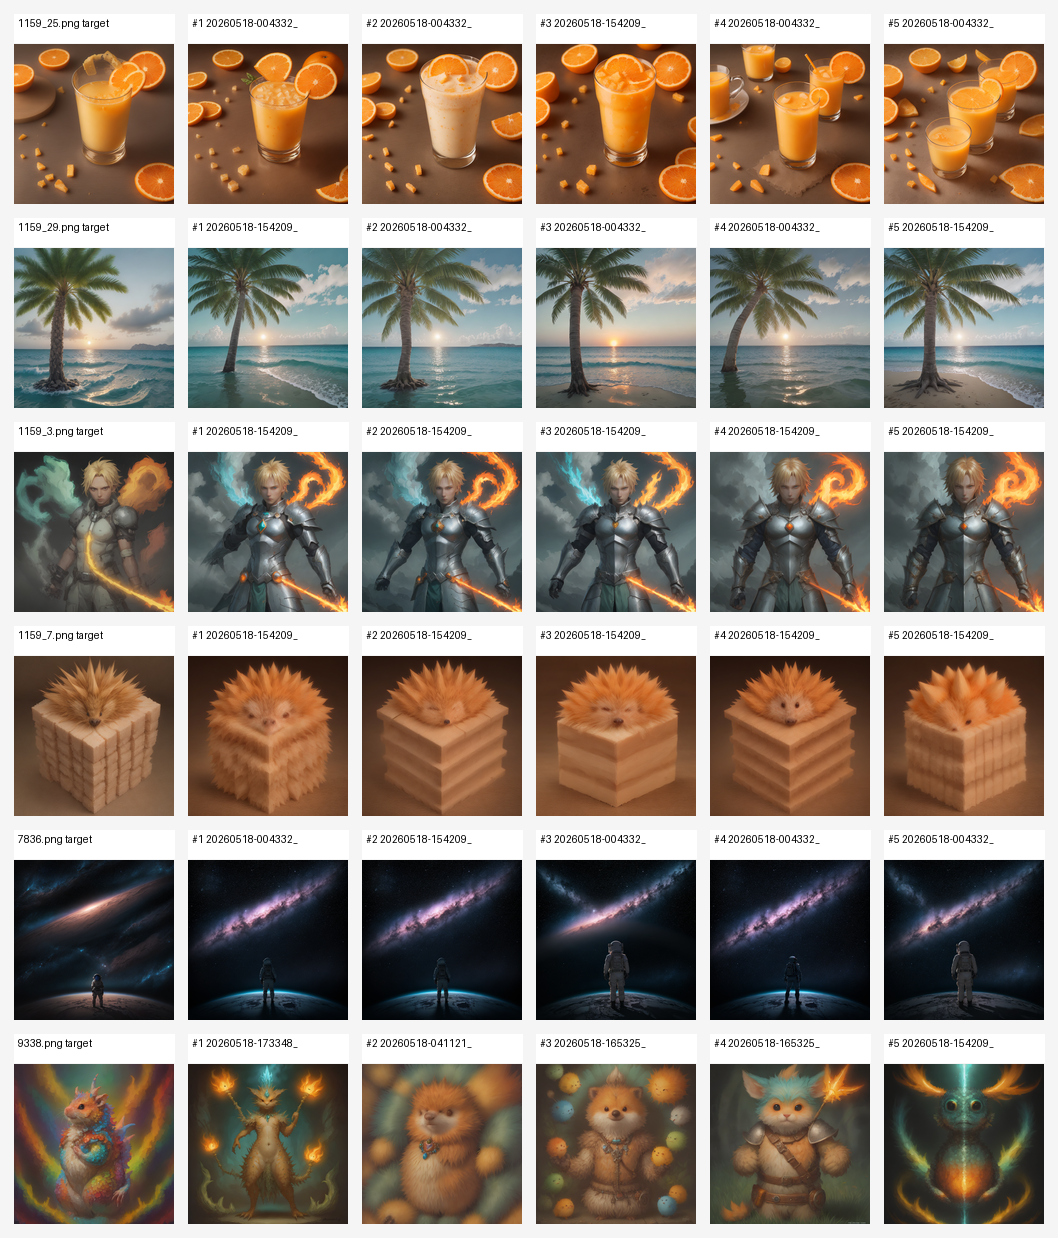

,target_name,cross_run_rank,run_name,candidate_index,clip_iisim,lpips_alex,pixel_rmse_01,pixel_ssim_01,cross_run_score,prompt
0,1159_25.png,1,20260518-004332_notebook_ronda_01_clip_guided_h...,28,0.941474,0.354101,0.133045,0.734755,0.971845,"photorealistic orange juice still life, small ..."
1,1159_25.png,2,20260518-004332_notebook_ronda_01_clip_guided_h...,22,0.928424,0.365230,0.146161,0.753050,0.815886,"pale orange smoothie in a straight glass, oran..."
2,1159_25.png,3,20260518-154209_notebook_ronda_03_visual_anchor,12,0.917813,0.388799,0.141190,0.747107,0.693841,single tall clear glass of pale creamy orange ...
3,1159_25.png,4,20260518-004332_notebook_ronda_01_clip_guided_h...,29,0.936085,0.420455,0.140670,0.690098,0.621935,"clear cylindrical orange juice glass, small or..."
4,1159_25.png,5,20260518-004332_notebook_ronda_01_clip_guided_h...,24,0.935036,0.445909,0.141597,0.727821,0.553855,single clear glass of pale creamy orange juice...
5,1159_29.png,1,20260518-154209_notebook_ronda_03_visual_anchor,54,0.925262,0.504083,0.142399,0.739021,0.885066,single slender palm tree rising from shallow t...
6,1159_29.png,2,20260518-004332_notebook_ronda_01_clip_guided_h...,23,0.914195,0.481167,0.138392,0.741326,0.806166,single slender palm tree in calm turquoise wat...
7,1159_29.png,3,20260518-004332_notebook_ronda_01_clip_guided_h...,38,0.918358,0.510646,0.152515,0.735173,0.722235,single slender palm tree in calm turquoise wat...
8,1159_29.png,4,20260518-004332_notebook_ronda_01_clip_guided_h...,29,0.912762,0.497672,0.146105,0.716775,0.675443,"delicate palm tree isolated in shallow ocean, ..."
9,1159_29.png,5,20260518-154209_notebook_ronda_03_visual_anchor,20,0.912073,0.553081,0.153156,0.723628,0.509756,single slender palm tree rising from shallow t...


In [10]:
# Compare previous top-k runs without rendering new images.

from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

BEST_OF_TOP_N = 5
BEST_OF_TARGETS = None  # e.g. ["1159_29.png", "9338.png"] or None for every available target


def bestof_candidate_output_dirs():
    candidates = [
        OUTPUT_DIR,
        Path("outputs"),
        Path("students/outputs"),
        Path("TP2-students/students/outputs"),
        Path("TP2-students/students/students/outputs"),
    ]
    seen = set()
    result = []
    for candidate in candidates:
        candidate = Path(candidate)
        key = str(candidate.resolve()) if candidate.exists() else str(candidate)
        if key not in seen and candidate.exists():
            seen.add(key)
            result.append(candidate)
    return result


def bestof_read_csv(path):
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")


def bestof_good(values, higher_is_better):
    values = np.asarray(values, dtype=np.float64)
    lo, hi = float(values.min()), float(values.max())
    if abs(hi - lo) < 1e-12:
        return np.full_like(values, 0.5, dtype=np.float64)
    scaled = (values - lo) / (hi - lo)
    return scaled if higher_is_better else 1.0 - scaled


BESTOF_DEFAULT_SCORE_WEIGHTS = {"clip": 0.35, "lpips": 0.40, "rmse": 0.15, "ssim": 0.10}
BESTOF_SCORE_WEIGHTS_BY_TARGET = {
    "9338.png": {"clip": 0.25, "lpips": 0.35, "rmse": 0.20, "ssim": 0.20},
    "1159_3.png": {"clip": 0.40, "lpips": 0.30, "rmse": 0.20, "ssim": 0.10},
    "1159_7.png": {"clip": 0.15, "lpips": 0.45, "rmse": 0.20, "ssim": 0.20},
    "1159_25.png": {"clip": 0.30, "lpips": 0.45, "rmse": 0.15, "ssim": 0.10},
    "1159_29.png": {"clip": 0.40, "lpips": 0.35, "rmse": 0.15, "ssim": 0.10},
    "7836.png": {"clip": 0.20, "lpips": 0.20, "rmse": 0.25, "ssim": 0.35},
}


def bestof_weights_for_target(target_name):
    weights = dict(BESTOF_DEFAULT_SCORE_WEIGHTS)
    weights.update(BESTOF_SCORE_WEIGHTS_BY_TARGET.get(target_name, {}))
    total = sum(float(value) for value in weights.values()) or 1.0
    return {key: float(value) / total for key, value in weights.items()}


def bestof_fit_square(image, size):
    image = image.copy()
    image.thumbnail((size, size), Image.Resampling.LANCZOS)
    canvas = Image.new("RGB", (size, size), "white")
    canvas.paste(image, ((size - image.width) // 2, (size - image.height) // 2))
    return canvas


def bestof_draw_label(draw, xy, text, width, font):
    x, y = xy
    draw.rectangle((x, y, x + width, y + 28), fill=(255, 255, 255))
    draw.text((x + 4, y + 3), text[:42], fill=(0, 0, 0), font=font)


top_paths = []
for base_dir in bestof_candidate_output_dirs():
    for top_path in sorted(base_dir.glob("*/top*.csv")):
        if "partial" not in top_path.stem:
            top_paths.append(top_path)

tables = []
for top_path in top_paths:
    table = bestof_read_csv(top_path)
    if table.empty or "target_name" not in table.columns:
        continue
    table = table.copy()
    table["run_name"] = top_path.parent.name
    table["top_csv"] = str(top_path)
    if "render_path" not in table.columns and "render" in table.columns:
        table["render_path"] = table["render"]
    tables.append(table)

if not tables:
    raise FileNotFoundError("No top-k CSV files found in output folders.")

bestof_df = pd.concat(tables, ignore_index=True)
if BEST_OF_TARGETS:
    bestof_df = bestof_df[bestof_df["target_name"].isin(BEST_OF_TARGETS)].copy()

metric_cols = ["clip_iisim", "lpips_alex", "pixel_rmse_01"]
optional_metric_cols = ["pixel_ssim_01"]
for col in metric_cols + optional_metric_cols:
    if col not in bestof_df.columns:
        bestof_df[col] = np.nan
    bestof_df[col] = pd.to_numeric(bestof_df[col], errors="coerce")
bestof_df = bestof_df.dropna(subset=metric_cols + ["render_path"])
bestof_df = bestof_df[bestof_df["render_path"].map(lambda path: Path(str(path)).exists())].copy()

scored_groups = []
for target_name, group in bestof_df.groupby("target_name", sort=True):
    group = group.copy()
    clip_good = bestof_good(group["clip_iisim"], True)
    lpips_good = bestof_good(group["lpips_alex"], False)
    rmse_good = bestof_good(group["pixel_rmse_01"], False)
    if group["pixel_ssim_01"].notna().any():
        filled_ssim = group["pixel_ssim_01"].fillna(group["pixel_ssim_01"].median())
        ssim_good = bestof_good(filled_ssim, True)
    else:
        ssim_good = np.full(len(group), 0.5, dtype=np.float64)
    weights = bestof_weights_for_target(target_name)
    group["cross_run_score"] = (
        weights["clip"] * clip_good +
        weights["lpips"] * lpips_good +
        weights["rmse"] * rmse_good +
        weights["ssim"] * ssim_good
    )
    scored_groups.append(group.sort_values("cross_run_score", ascending=False).head(BEST_OF_TOP_N))

bestof_ranked = pd.concat(scored_groups, ignore_index=True)
bestof_ranked["cross_run_rank"] = bestof_ranked.groupby("target_name")["cross_run_score"].rank(method="first", ascending=False).astype(int)

bestof_dir = Path(OUTPUT_DIR) / "best_of_runs"
bestof_dir.mkdir(parents=True, exist_ok=True)
bestof_csv = bestof_dir / "best_of_runs.csv"
bestof_ranked.to_csv(bestof_csv, index=False)

thumb = 160
label_height = 30
gap = 14
columns = BEST_OF_TOP_N + 1
row_height = thumb + label_height + gap
sheet_width = columns * thumb + (columns + 1) * gap
sheet_height = bestof_ranked["target_name"].nunique() * row_height + gap
sheet = Image.new("RGB", (sheet_width, sheet_height), (245, 245, 245))
draw = ImageDraw.Draw(sheet)
font = ImageFont.load_default()

target_by_name = {Path(path).name: path for path in target_images}
for row_index, (target_name, group) in enumerate(bestof_ranked.groupby("target_name", sort=True)):
    y = gap + row_index * row_height
    target_path = target_by_name.get(target_name)
    if target_path:
        target_image = bestof_fit_square(load_image(target_path), thumb)
        sheet.paste(target_image, (gap, y + label_height))
        bestof_draw_label(draw, (gap, y), f"{target_name} target", thumb, font)

    for col_index, (_, row) in enumerate(group.sort_values("cross_run_rank").iterrows(), start=1):
        x = gap + col_index * (thumb + gap)
        render_image = bestof_fit_square(load_image(row["render_path"]), thumb)
        sheet.paste(render_image, (x, y + label_height))
        label = f"#{int(row['cross_run_rank'])} {row['run_name'][:16]}"
        bestof_draw_label(draw, (x, y), label, thumb, font)

bestof_sheet = bestof_dir / "contact_sheet_best_of_runs.jpg"
sheet.save(bestof_sheet, quality=92)
print("Saved:", bestof_csv)
print("Saved:", bestof_sheet)
display(sheet)

bestof_ranked[["target_name", "cross_run_rank", "run_name", "candidate_index", "clip_iisim", "lpips_alex", "pixel_rmse_01", "pixel_ssim_01", "cross_run_score", "prompt"]]


## 7. Export Current Top Picks

This copies the current best-of rank 1 image per target after ronda_03 into one folder for quick manual inspection.


In [11]:
# Export best-of rank 1 per target into outputs/final_selection_preview.
# This is only a preview: after looking at the contact sheet, manual judgement still wins.

import shutil
from pathlib import Path

if "bestof_ranked" not in globals():
    raise NameError("Run the best-of cell before exporting the preview selection.")

preview_dir = Path(OUTPUT_DIR) / "final_selection_preview"
preview_dir.mkdir(parents=True, exist_ok=True)
selected = bestof_ranked.sort_values(["target_name", "cross_run_rank"]).groupby("target_name", as_index=False).first()
selected_csv = preview_dir / "final_selection_preview.csv"
selected.to_csv(selected_csv, index=False)

for _, row in selected.iterrows():
    source = Path(str(row["render_path"]))
    if source.exists():
        dest = preview_dir / f"{Path(str(row['target_name'])).stem}_rank1_{row['run_name']}_cand{int(row['candidate_index']):03d}.png"
        shutil.copy2(source, dest)

print("Saved:", selected_csv)
print("Saved images to:", preview_dir)
selected[["target_name", "run_name", "candidate_index", "cross_run_score", "prompt"]]


Saved: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\outputs\final_selection_preview\final_selection_preview.csv
Saved images to: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\outputs\final_selection_preview


,target_name,run_name,candidate_index,cross_run_score,prompt
0,1159_25.png,20260518-004332_notebook_ronda_01_clip_guided_h...,28,0.971845,"photorealistic orange juice still life, small ..."
1,1159_29.png,20260518-154209_notebook_ronda_03_visual_anchor,54,0.885066,single slender palm tree rising from shallow t...
2,1159_3.png,20260518-154209_notebook_ronda_03_visual_anchor,14,0.855624,single blond anime warrior mage in reflective ...
3,1159_7.png,20260518-154209_notebook_ronda_03_visual_anchor,19,0.945017,small hedgehog with compact cubical wooden blo...
4,7836.png,20260518-004332_notebook_ronda_01_clip_guided_h...,4,0.891683,"small space explorer at bottom edge, sloping p..."
5,9338.png,20260518-173348_notebook_ronda_05_visual_metric...,31,0.777911,"upright fantasy spiny creature, orange animal ..."
